# Class 17: Boundary Value Problems 

Ch. 8, section 6: Boundary Value and Eigenvalue Problems 

- Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Shooting Method

#### Book example 8.8 - Vertical position of a thrown ball

Let's solve the problem above with the thrown ball for the case where the ball lands back at $x=0$ after $t = 10$ seconds. 
$$\frac{d^2x}{dt^2} = -g $$

**First step**: break down second-order differential equation into two first-orders:


$$ \frac{dx}{dt} = y \qquad \frac{dy}{dt} = -g $$

**Solve** For the initial velocity using Runge-Kutta and Binary Search 

Binary Search Outline: 
1) Given an initial pair of points $x_1, x_2$ check that $f(x_1)$ and $f(x_2)$ have opposite signs. Also choose a target accuracy for the answer you want. 

2) Calculate the midpoint $x' = \frac{1}{2}(x_1+x_2)$ and evaluate $f(x')$

3) If $f(x')$ has the same sign as $f(x_1)$ then set $x_1 = x'$. Otherwise set $x_2 = x'$. 

4) If $|{x_1-x_2}|$ is greater than the target accuracy, repeat from step 2. Otherwise, calculate $\frac{1}{2}(x_1+x_2)$ once more and this is the final estimate of the position of the root. 


In [ ]:
#define constants needed for function
g = 9.81 #m/s^2



#define function for diff eqs

def f(r,t): #remember here r is a vector [x,v]
    x = r[0]
    v = r[1]

    fx = v
    fv = -g

    return np.array([fx,fv])



#use fourth order RK to calculate value of function f

def height(v,tpts,h): #v is initial guess and tpts is array of time values spaced by h

    r = np.array([0.0,v],float) #initial height 0, initial velocity (guess) v

    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1,t+0.5*h)
        k3 = h*f(r+0.5*k2,t+0.5*h)
        k4 = h*f(r+k3,t+h)
        r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return r[0] #we want from this the final height, which is the first index in r


tstart = 0 #s; starting time
tend = 10 #s

Npoints = 1000

h = (tend-tstart)/Npoints
tpoints = np.arange(tstart,tend+h,h)

#we now need to set up a binary search method that iterates over v guesses such that the final height returned from the function is 0
targetacc = 1e-10 #to be "close enough" to h


def binary_solve(x1,x2,f,acc): #function taken from my work in class notebook 13 and edited
    f1 = f(x1,tpoints,h)
    f2 = f(x2,tpoints,h)

    if f1*f2 < 0: #negative * positive always equals negative
        while abs(x2-x1) > acc:
            mid = 0.5*(x1+x2)
            fmid = f(mid,tpoints,h)
            if fmid*f1 > 0:
                x1 = mid
            elif fmid*f2 > 0:
                x2 = mid
        return 0.5*(x1+x2)
    else:
        return -999.99 #used in astronomy to inform that an answer is wrong
    

#initial values
v1 = 0.01 #shouldnt be zero because trivial soln
v2 = 1000.0 #not too high

james = binary_solve(v1,v2,height,targetacc)
print(james)


49.09905000002831


**Check** Plug back in as initial condition using Runge-Kutta to double-check final position 

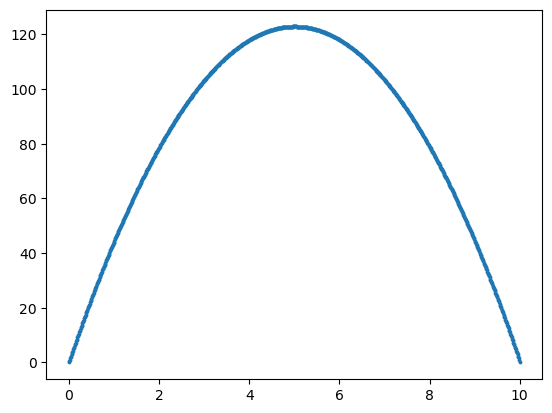

2.8113439354271463e-10


In [9]:
#define constants needed for function
g = 9.81 #m/s^2



#define function for diff eqs

def f(r,t): #remember here r is a vector [x,v]
    x = r[0]
    v = r[1]

    fx = v
    fv = -g

    return np.array([fx,fv])



tstart = 0 #s; starting time
tend = 10 #s

Npoints = 1000

h = (tend-tstart)/Npoints
tpoints = np.arange(tstart,tend+h,h)
xpoints = np.zeros(len(tpoints),float) #positions
vpoints = np.zeros(len(tpoints),float) #velocities

r = np.array([0.0,james])
#using 4th order RK to get a graph
for i in range(len(tpoints)):
    t = tpoints[i]
    xpoints[i],vpoints[i] = r[0],r[1]
    k1 = h*f(r,t)
    k2 = h*f(r+0.5*k1,t+0.5*h)
    k3 = h*f(r+0.5*k2,t+0.5*h)
    k4 = h*f(r+k3,t+h)
    r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
xpoints[i],vpoints[i] = r[0],r[1]

plt.scatter(tpoints,xpoints,s=3)
plt.show()

print(xpoints[-1])

#### What if...

What if the final condition on position had been a value rather than 0? 

**answer**: Since searching for when the `h1` and `h2` values straddle a root, just subtract the final height from each of them to make it a zero

### Eigenvalue Problems

Calculate the ground state energy of an electron in a square potential well with infinitely high walls separated by a distance $L$ equal to the Bohr radius $a_0 = 5.292 \times 10^{-11}$ m.

$$ \frac{d\psi}{dx} = \phi \qquad \frac{d\phi}{dx} = \frac{2m}{\hbar^2}\left[ V(x) -E \right] \psi $$

**Secant method - solution to noninear equations**

new, hopefully better estimate of root is given by: 
$$x_3 = x_2 - f(x_2) \frac{x_1-x_2}{f(x_1)-f(x_2)}$$
where the new estimate is based on the previous two values in the series 

In [11]:
#potential energy function
def V(x):
    return 0.0 #while inside the well


# constants
m = 9.1094e-31 # mass of an electron
hbar = 1.0546e-34 # planck's constnat over 2pi
e = 1.6022e-19 # electron charge
L = 5.2918e-11 # Bohr radius 
N = 1000 #number of points
h = L/N #step size, not planck constant

#define first order diff eqs
def f(r,x,E): #r is an array, x is the thing we're differentiating wrt, and E is the eigenvalue
    psi = r[0]
    phi = r[1]

    fpsi = phi
    fphi = (2*m)/(hbar**2) * (V(x)-E)*psi

    return np.array([fpsi,fphi],float)


#apply rk4 to calculate wavefunction for a particular energy

def wavefn_RK4(E):
    r = np.array([0.0,1.0],float) #initial guesses for psi and phi

    xpoints = np.arange(0,L+h,h)

    for t in xpoints: #t is spatial here, just different definition of variables
        k1 = h*f(r,t,E)
        k2 = h*f(r+0.5*k1,t+0.5*h,E)
        k3 = h*f(r+0.5*k2,t+0.5*h,E)
        k4 = h*f(r+k3,t+h,E)
        r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return r[0] #we want from this the final psi, which is r[0]


#determine energy using secant method

#initial guesses
E1 = 0.0
E2 = e 

target = e/1000 #difference between energies, smaller than usual because e is small [citation needed]


psi2 = wavefn_RK4(E1)

while abs(E1-E2) > target: #this in here is the secant method
    psi1,psi2 = psi2,wavefn_RK4(E2) #the old psi2 is the new psi1, and the new psi2 is redefined with the fn

    E1,E2 = E2,E2-psi2*(E1-E2)/(psi1-psi2) #eventually E2 is the final answer

print('The energy is',E2/e,'eV')






The energy is 134.0182012729446 eV


### Exercise 8.14(a) - if time

Consider the one-dimensional, time-independent Schroedinger equation in a harmonic (i.e., quadratic) potential $V(x) = V_0x^2/a^2$, where $V_0$ and $a$ are constants.

**a)** Write down the Schroedinger equation for this problem and convert it from a second- order equation to two first-order ones, as in Example 8.9. Write a program, or modify the one from Example 8.9, to find the energies of the ground state and the first two excited states for these equations when $m$ is the electron mass, $V_0 = 50$ eV, and $a = 10^{−11}$ m. Note that in theory the wavefunction goes all the way out to $x = \pm \infty$, but you can get good answers by using a large but finite interval. Try using $x = −10a$ to $+10a$, with the wavefunction $\psi = 0$ at both boundaries. (In effect, you are putting the harmonic oscillator in a box with impenetrable walls.) The wavefunction is real everywhere, so you don’t need to use complex variables, and you can use evenly spaced points for the solution—there is no need to use an adaptive method for this problem.

The quantum harmonic oscillator is known to have energy states that are equally spaced. Check that this is true, to the precision of your calculation, for your answers. (Hint: The ground state has energy in the range 100 to 200 eV.)

In [ ]:



# constants
m = 9.1094e-31 # mass of an electron
hbar = 1.0546e-34 # planck's constnat over 2pi
e = 1.6022e-19 # electron charge
V0 = 50*e